## TOPAZ: TOpologically-based Parameter inference for Agent-based model optimiZation

This code has three big sections with two additional optionals steps: the simulation or topological data analysis (TDA) step, the parameter estimation step using approximate Bayesian computation (ABC), the (optional) approximate approximate Bayesian computation (AABC), the (optional) statistical verification step using PERMANOVA, Energy Distance, and/or MMD tests, and the Bayesian information criterion step (BIC).


<img src="TOPAZ_figure.png" alt="Figure detailing TOPAZ pipeline" width="800"/>

In [3]:
# necessary imports needed throughout
from IPython.display import Image,display, HTML
import numpy as np

### Step 1: Topological Data Analysis

#### 1.1 Simulate the ABM simulation

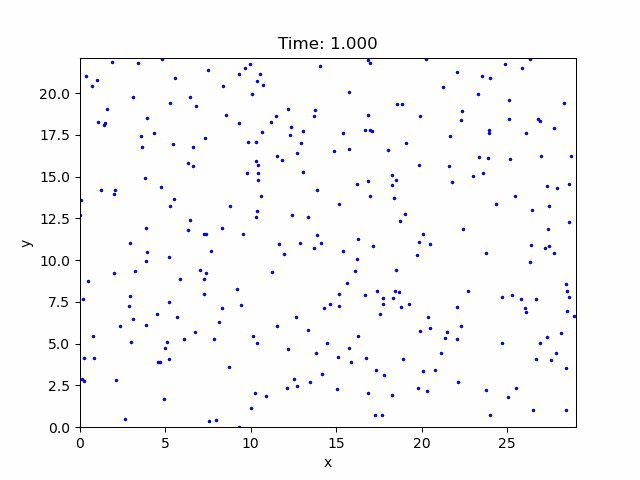

In [6]:
from Modules_CLW.TDA1_run_CLW_sim import run_CLW_sim

'''Run ABM simulation for chosen values of C, L, and W over a specified time period

Inputs:
    C - Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter
    T0 - Initial time of simulation
    TF - End time of simulation
    DT - How often to make a new frame of data
    num_agents - number of cell agents to be in the simulation

Requirements:
    ic_vec.npy - vector of initial conditions
    
Output: 
    df.pkl - the resulting TDA dataframe of cells over the simulation
    TDA_simulation.gif - gif of chosen C,L,W simulation
    
'''
# pick the inputs 
# Pick C between 1 and 30
C = 17
# Pick L between 1 and 30
L = 3
# Pick W between 0 and 10
W = 5

T0 = 1
TF = 21
DT = 1/6

num_agents = 300

# run the simulation
run_CLW_sim(C,L,W,T0,TF,DT,num_agents)

# display simulation gif
CLW_gif_name = f"Chosen_C_{str(C).zfill(2)}_L_{str(L).zfill(2)}_W_{str(W).zfill(2)}/TDA_simulation.gif"
display(Image(filename=CLW_gif_name, embed=True))

This simulation will represent our "ground truth" baseline moving forward.

#### 1.2 Run TDA to get the Betti-0 and Betti-1 crocker matrices for your (C, L, W) combination

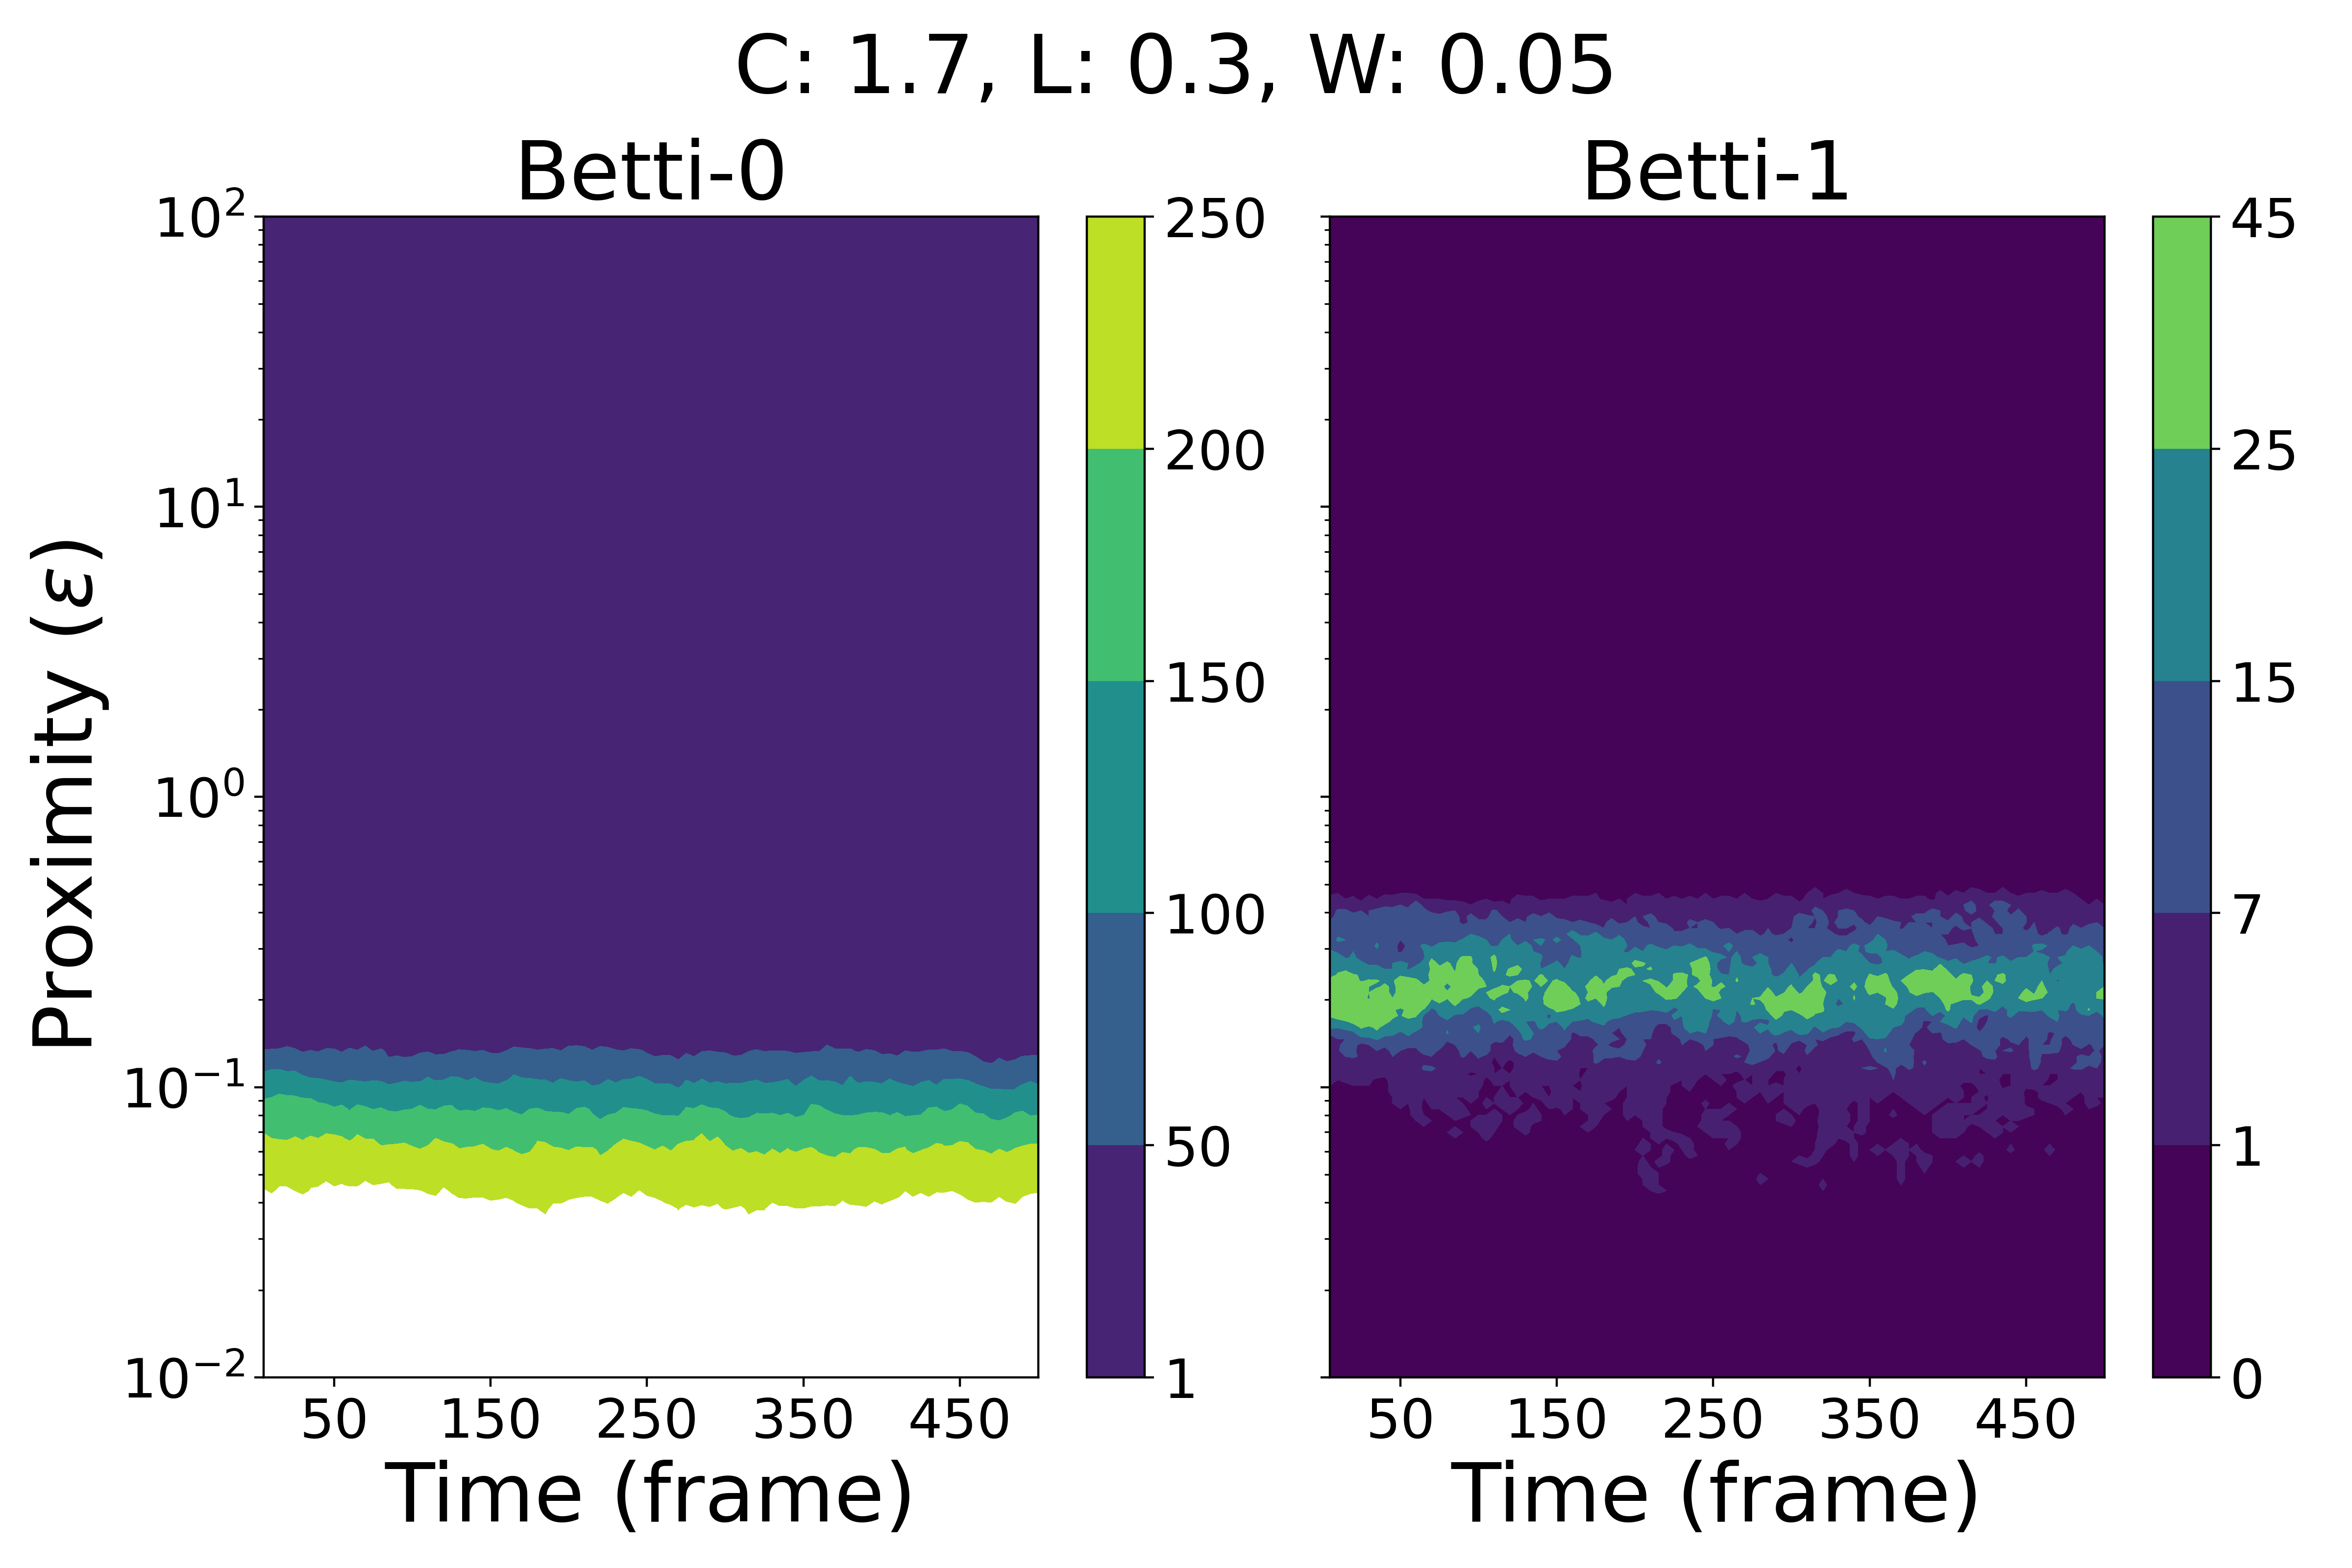

In [9]:
from Modules_CLW.TDA2_get_crockers import get_crockers

'''Compute crockers for specific Betti numbers given a trajectory dataframe.

Inputs:
    C -  Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter

Requirements: 
    df.pkl - the resulting TDA dataframe of cells over the simulation
    
Output: 
    crocker_angles.npy - the array of crocker angles that form the crocker plot
    
'''

# calculate the crocker plot
crockers = get_crockers(C,L,W)

# display crocker plot 
CLW_crocker_name = f"Chosen_C_{str(C).zfill(2)}_L_{str(L).zfill(2)}_W_{str(W).zfill(2)}/crocker_plot.png"
display(Image(filename=CLW_crocker_name, width=600))

### Step 2: Approximate Bayesian Computation

#### 2.1 Generate random samples

The goal is to run a large amount of ABC simulations. However, this is a very time and space consuming process. A sample of 30 random simulations has been pre-run but for more thourough analysis, closer to 10,000 samples is recommended.

In [13]:
from Modules_CLW.ABC1_run_ABC_once import run_ABC_once

'''Run ABM simulation for random values of C,L,W over a specified time period

Inputs:
    T0 - Initial time of simulation
    TF - End time of simulation
    DT - How often to make a new frame of data
    num_agents - number of cell agents to be in the simulation
    
Requirements:
    ic_vec.npy - vector of initial conditions
    
Output: 
    df.pkl - the resulting dataframe of cells over the simulation with random C, L, and W values
    pars.npy - file of parameters used in random simulation
    random_ABC_simulation.gif - gif of random C,L,W simulation
    
'''

# if you want to run one random simulation, you can do so here 
single_random_ABC = run_ABC_once(T0,TF,DT,num_agents)

# display simulation gif
display(HTML('<img src="single_ABC_sample/random_ABC_simulation.gif">'))

# example path to one of 30 simulations 
example_sample_path = './sample_30/run_1/df.pkl'

#### 2.2 Calculate crocker plots for random samples 

This step is also very time consuming and similarly has been uploaded with an option to calculate the crocker plot for the single simulation ran in the previous step. 

In [16]:
from Modules_CLW.ABC2_run_ABC_crocker_once import run_ABC_crocker_once

'''Compute crockers for specific Betti numbers given a trajectory dataframe for random C,L,W values

Inputs:
    
Requirements:
    df.pkl - the resulting dataframe of cells over the simulation with random C, L, and W values
    
Output: 
    crocker_angles.npy - crocker values of random C,L,W simulation
    
'''

# calculate the crocker plot of your one random sample
single_random_ABC = run_ABC_crocker_once()

# example path to one of 30 simulations 
example_crocker_path = './sample_30/run_1/crocker_angles.npy'

#### 2.3 Calculate samples losses for each crocker plot 

Now we will begin comparing our ABC results to our ground truth simulation from step 1. 

In [19]:
from Modules_CLW.ABC3_compute_losses import compute_losses

'''Compute sample losses between ground truth and random ABC simulations and crocker plots 

Inputs:
    C - Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter
    samples_path - path to the 30 random samples
    num_samples - number of samples contained in samples_path

Requirements:
    (Chosen) crocker_angles.npy - crocker values of chosen C,L,W simulation
    (Random) crocker_angles.npy - crocker values of random C,L,W simulation
    pars.npy - file of parameters used in random simulation
    
Output: 
    sample_losses_angles.npy - file of sample losses calculated for the 30 samples 
    
'''
samples_path = './sample_30'
num_samples = 30
sample_losses = compute_losses(C,L,W,samples_path,num_samples)

#### 2.4 Calculate ABC medians and posterior density plots 

From the sample losses, we can calculate the median values for ABC and create corresponding posterior density plots. 

In [22]:
from Modules_CLW.ABC4_medians import compute_medians_and_densities

'''Create posterior density plots for calculated sample losses and median ABC estimated values for C,L,W

Inputs:
    C - Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter

Requirements:
    sample_losses_angles.npy - file of sample losses calculated for the 30 samples 
    
Output: 
    ABC_posterior_densities - folder containing 11 2D ABC posterior slices (1 for each W value)
    medians - ABC estimated median values for C,L,W
    posteriors.npy - posteriors that generated ABC_posterior_densities
    
'''

medians = compute_medians_and_densities(C,L,W)

print('Medians: C='+str(medians[0])+' L='+str(medians[1])+' W='+str(medians[2]))

#output posterior density plots 
# for W_slice in range(11):
#     post_slices_name = f"Chosen_C_{str(C).zfill(2)}_L_{str(L).zfill(2)}_W_{str(W).zfill(2)}/ABC_posterior_densities/posterior_density_slice_at_w{str(W_slice).zfill(2)}.png"
#     display(Image(filename=post_slices_name, width=100))

html = ""
for W_slice in range(11):
    post_slices_name = f"Chosen_C_{str(C).zfill(2)}_L_{str(L).zfill(2)}_W_{str(W).zfill(2)}/ABC_posterior_densities/posterior_density_slice_at_w{str(W_slice).zfill(2)}.png"
    html += f'<img src="{post_slices_name}" width="200" style="margin-right:10px;" />'

display(HTML(html))

Medians: C=1.7427116113401528 L=0.5221245857380127 W=0.0730843154768611


#### 2.5 Run the ABC model simulations

Next we will run the ABC medians through our ABM simulation. 

In [25]:
from Modules_CLW.ABC5_run_ABC_sim import run_ABC_sim

'''Run ABM simulation for ABC median estimated values of C, L, and W over a specified time period

Inputs:
    C - Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter
    T0 - Initial time of simulation
    TF - End time of simulation
    DT - How often to make a new frame of data
    num_agents - number of cell agents to be in the simulation

Requirements:
    ic_vec.npy - vector of initial conditions
    sample_losses_angles.npy - file of sample losses calculated for the 30 samples 
    
Output: 
    df_ABC.pkl - the resulting dataframe of cells over the simulation with random C, L, and W values
    medians.npy - the ABC median values 
    ABC_med_simulation.gif - gif of random C,L,W simulation
    
'''

run_ABC_sim(C,L,W,T0,TF,DT,num_agents)

# display simulation gif
ABC_med_gif_name = f"Chosen_C_{str(C).zfill(2)}_L_{str(L).zfill(2)}_W_{str(W).zfill(2)}/ABC_med_simulation.gif"
display(HTML(f'<img src="{ABC_med_gif_name}" />'))

#### 2.6 Calculate the ABC crocker plots 

From the simulation, we can create an ABC crocker plot. 

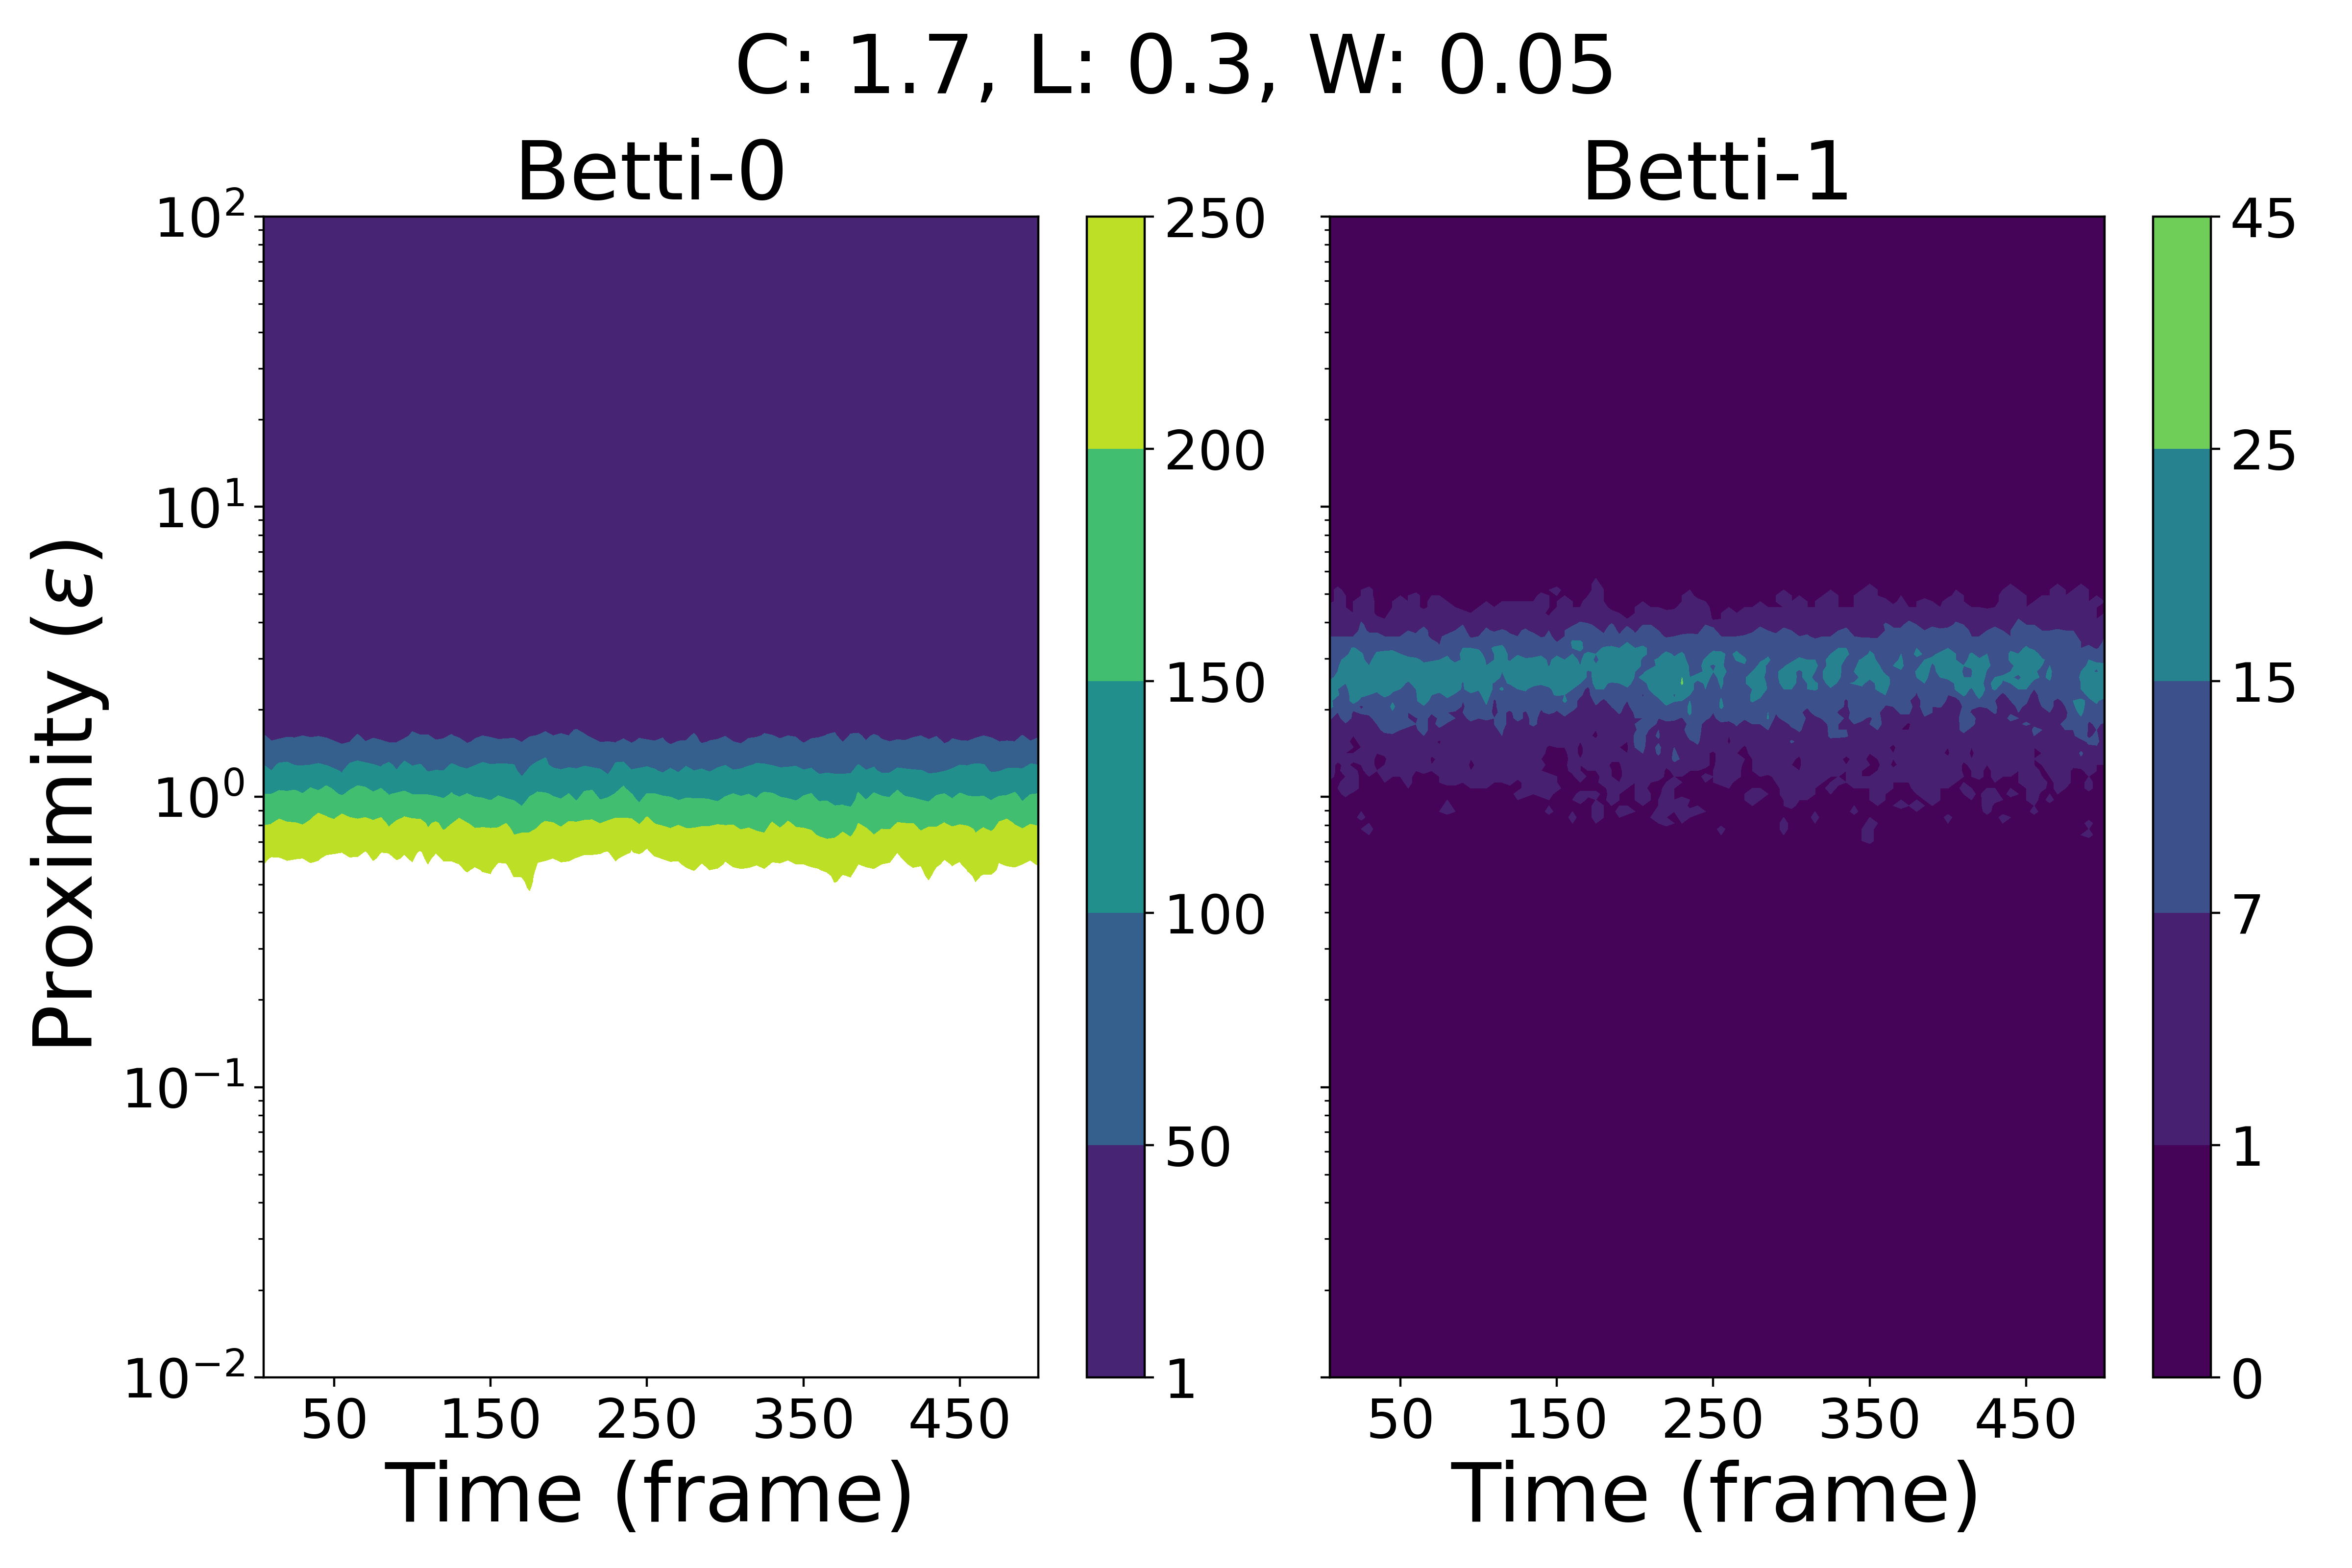

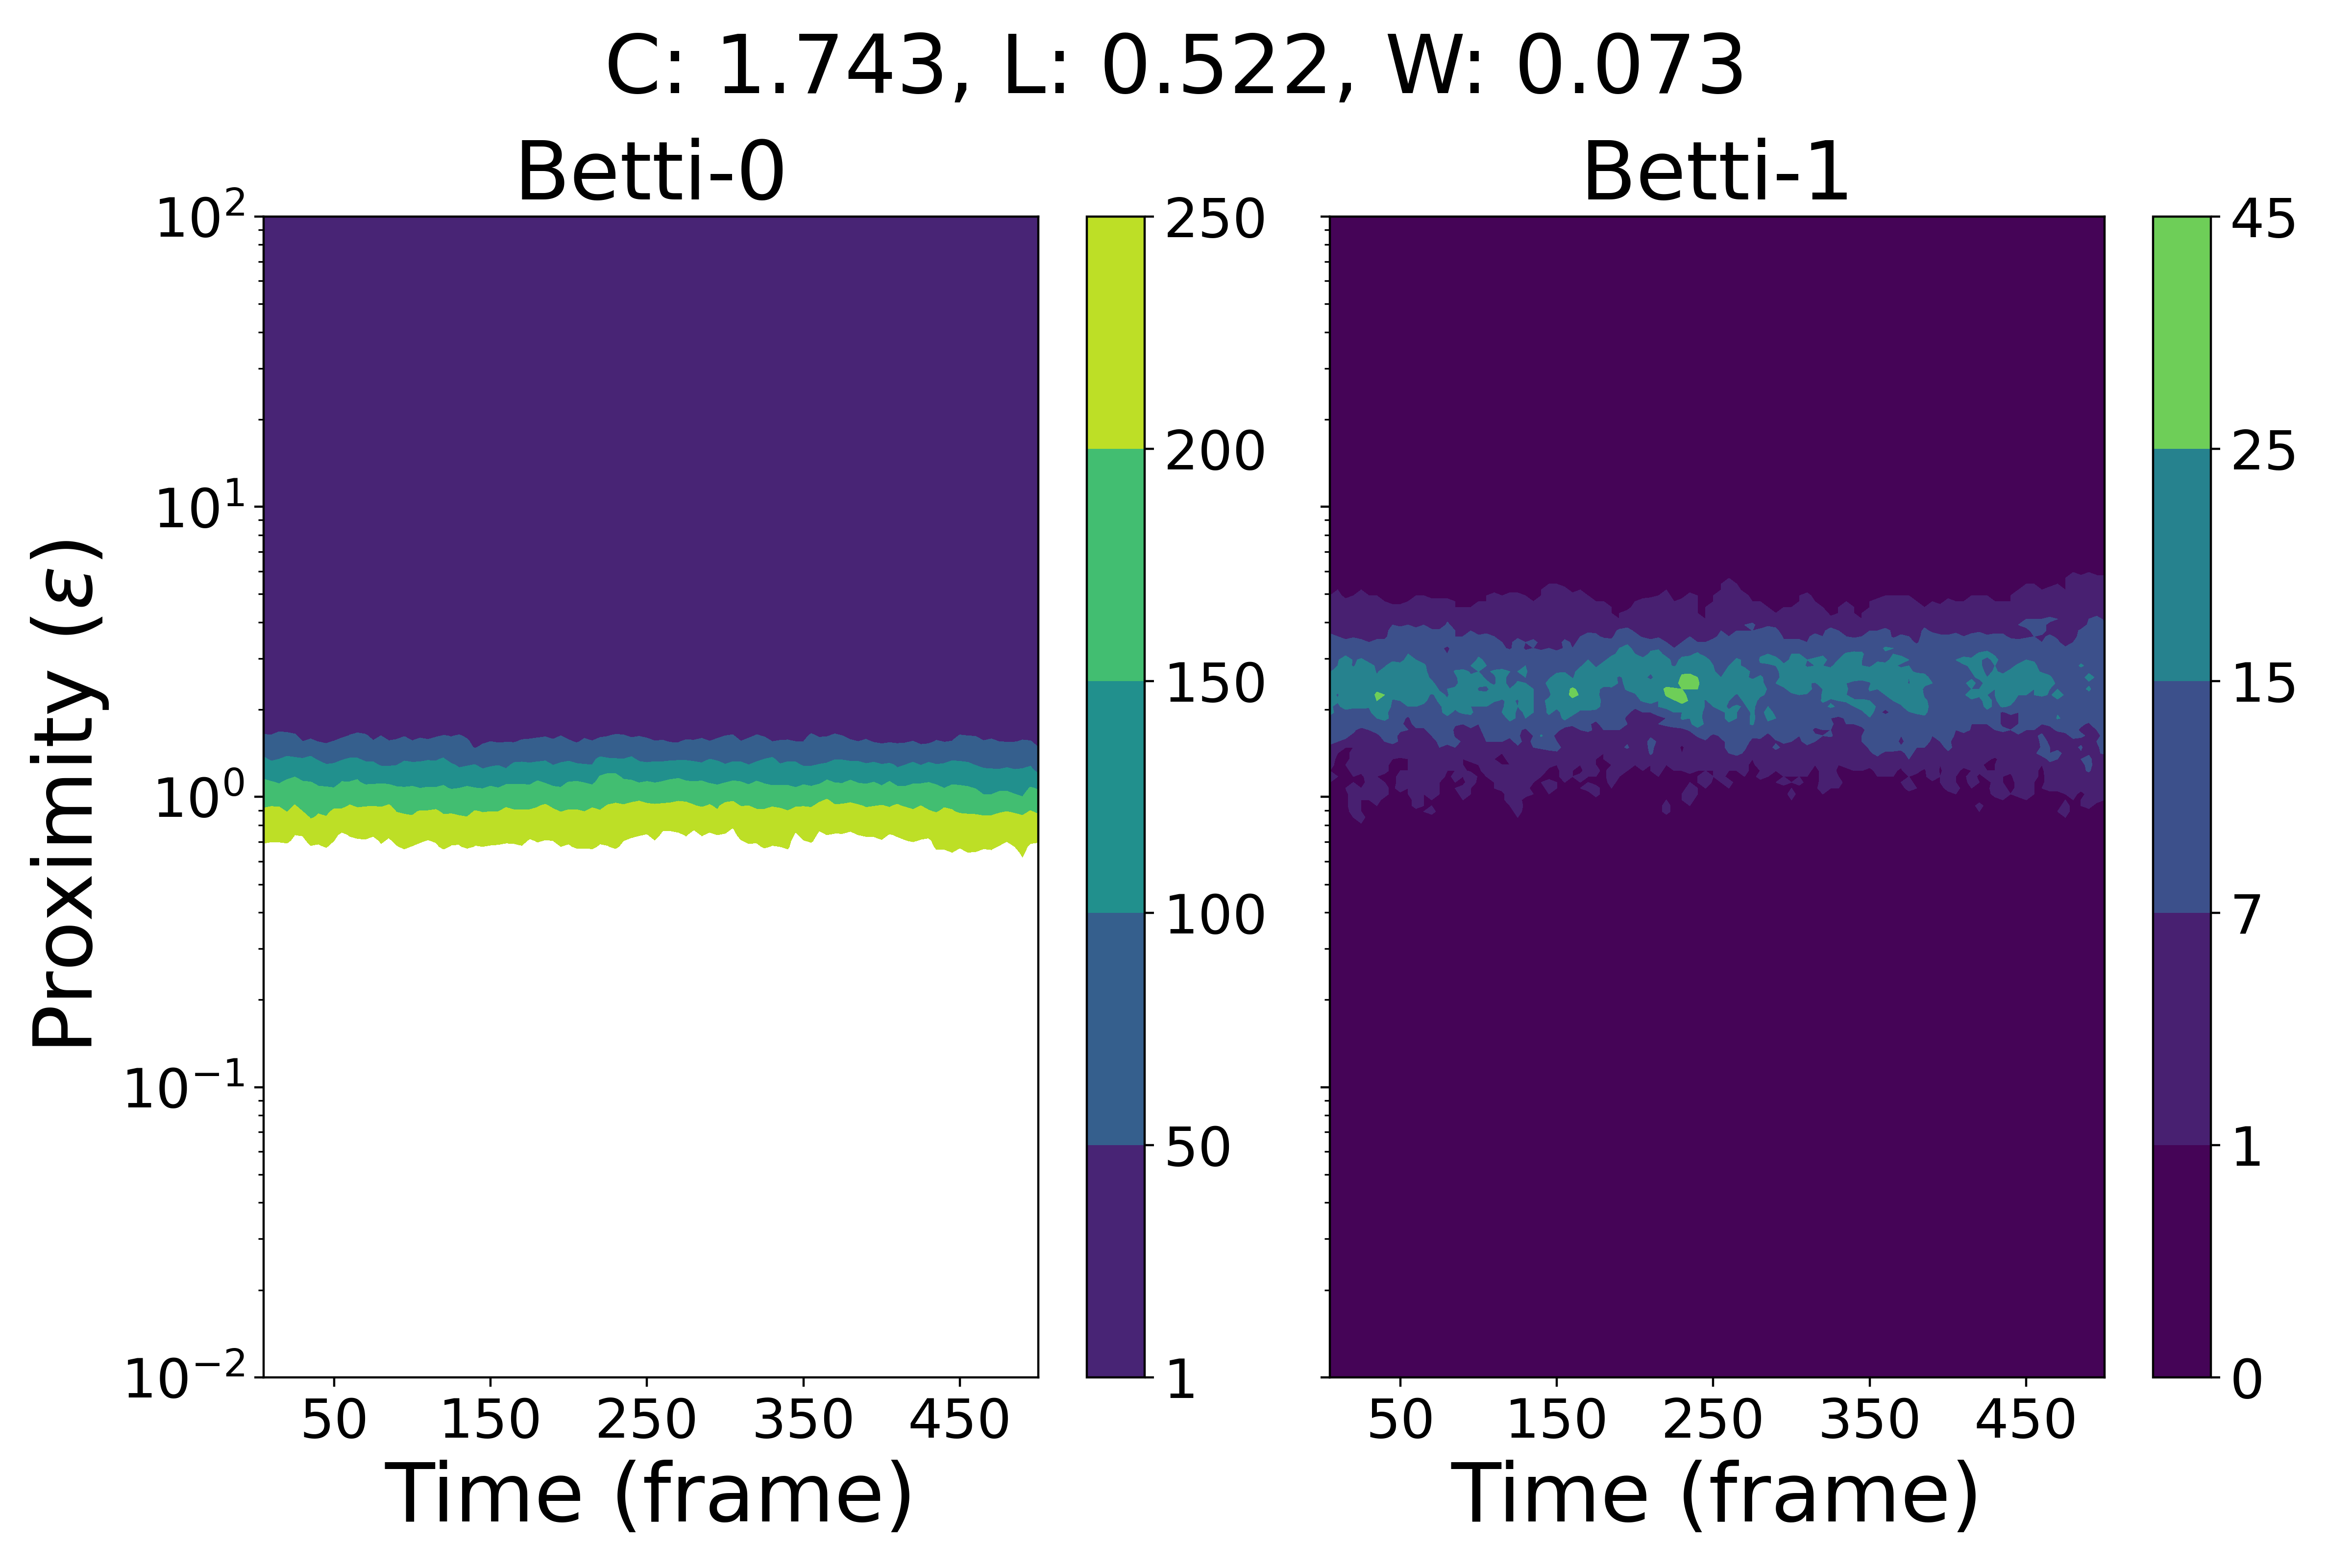

In [28]:
from Modules_CLW.ABC6_run_ABC_crocker import run_ABC_crocker

'''Compute crockers for specific Betti numbers given a trajectory dataframe for ABC median estimated C,L,W values

Inputs:
    C - Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter
    T0 - Initial time of simulation
    TF - End time of simulation
    DT - How often to make a new frame of data
    num_agents - number of cell agents to be in the simulation

Requirements:
    df.pkl - Ground truth data frame simulation
    medians.npy - ABC median values
    df_ABC.pkl - ABC median data frame simulation
    
Output: 
    true_crocker.png - Ground truth crocker plot 
    ABC_crocker.png - ABC median crocker plot 
    crocker_differences.npy - calculated difference between the two crocker plots 
    
'''

run_ABC_crocker(C,L,W,T0,TF,DT,num_agents)

# display true crocker plot 
true_crocker_name = f"Chosen_C_{str(C).zfill(2)}_L_{str(L).zfill(2)}_W_{str(W).zfill(2)}/true_crocker.png"
display(Image(filename=true_crocker_name, width=600))

# display ABC crocker plot 
ABC_crocker_name = f"Chosen_C_{str(C).zfill(2)}_L_{str(L).zfill(2)}_W_{str(W).zfill(2)}/ABC_crocker.png"
display(Image(filename=ABC_crocker_name, width=600))

### Step 2a (Optional): Approximate Approximate Bayesian Computation

Now let's say that you decide that 30 (or 10,000) samples isn't enough samples but it would take too long to generate more samples using ABC as you did before. That is where the AABC step comes in as a quicker way to generate more samples. Let's generate 120 more samples so we will have a total of 150 samples instead of 30 samples. 

#### 2a.1 Shrink the Grid (skipped but optional)

Before running the AABC step, we would normally shrink the grid but due to not wanting to take too long or take up too much space on GitHub, we have chosen to skip it for this tutorial. But we will include a placeholder below. 

If you choose to shrink the grid, you will need to run new base ABC simulations to use in the AABC process. Since we are skipping this step, we will use the original 30 samples from above moving forward. If you do choose to create new samples on a smaller grid, it is recommended to run those samples through the original ABC/BIC steps above to generate a baseline to compare the new AABC samples too. 


In [33]:
'''Go through posterior density plots and decide on a smaller, denser grid to run the AABC step on. 
    
'''

# Chosen grid size moving forward
# Ours is the original gridsize
parameter_bounds = np.array([
    [0.0, 3.0],  # C: update
    [0.0, 3.0],  # L: update
    [0.0, 0.1],  # W: update
], dtype=float)

# Then you need to run ABC steps 2.1 and 2.2 to generate new ABC samples to use an inputs below 
# Would recommend running steps 2.3-2.6 and 3.1 as baseline as well but optional

#### 2a.2 Extract Parameter Values and Flatten Crockers from ABC Samples

The AABC method requires on array of parameter values used in the original samples (either from the full grid or smaller grid above) and the Crocker angles flattened into one array. 

In [36]:
from Modules_CLW.AABC1_get_params_n_crockers import get_params_n_crockers_aabc

'''Extract the parameters used in ABC samples and flatten Crocker matrices generated in ABC samples

Inputs:
    samples_path - path to ABC samples to use in AABC (whether original samples or smaller grid samples)
    C - Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter

Requirements:
    crocker_angles.npy - crocker values of random sampled C,L,W simulations
    pars.npy - file of parameters used in random sampled C,L,W simulations
        
Output: 
    all_params.npy - All of the parameters used in the orignal samples 
    all_crockers_flattened.npy - All of the Crockers generated in the original samples flattened
    
'''

[params, crockers] = get_params_n_crockers_aabc(samples_path,C,L,W)

#### 2a.3 AABC Simulations

Either using the original samples as we will do or using your newly generated samples, we will now create the new AABC samples. In this case, we will generate 120 new samples for a total of 150 samples. 

In [39]:
from Modules_CLW.AABC2_run_samples import run_samples_aabc

'''Generate new samples using AABC methodology

Inputs:
    num_aabc_samples - The number of AABC samples to run
    k - The number of nearest neighbors to use in AABC method
    C - Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter
    parameter_bounds - Values of lower and upper bounds for C, L, W grids
    n_workers : int; Number of processes (default is 4; ignored if use_multiprocessing=False)
    use_multiprocessing : bool; Whether to use ProcessPoolExecutor (default is False)

Requirements:
    all_params.npy - All of the parameters used in the orignal samples 
    all_crockers_flattened.npy - All of the Crockers generated in the original samples flattened
        
Output: 
    theta_star.npy/sampled_params - np.ndarray, shape (NUM_SAMPLES, 3); The new sampled parameter values
    crocker_angles_aabc.npy - Crocker files of new AABC samples
    
'''

num_aabc_samples = 150 
k = 5

sampled_params = run_samples_aabc(num_aabc_samples, k, C, L, W, parameter_bounds)

#### 2a.4 ABC+AABC Sample Loss Calculation

Similar to step 2.3 above, we will calculate the sample losses but this time for the original (or smaller grid) samples and the newly-generated AABC samples together. 

In [42]:
from Modules_CLW.AABC3_compute_losses import compute_losses_aabc

'''Compute sample losses between ground truth and random ABC+AABC simulations and crocker plots 

Inputs:
    C - Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter
    samples_path - path to ABC samples to use in AABC (whether original samples or smaller grid samples)
    total_num_samples - number of samples contained in samples_path and number of AABC samples generated above

Requirements:
    (Chosen) crocker_angles.npy - crocker values of chosen C,L,W simulation
    (Random) crocker_angles.npy - crocker values of random C,L,W simulation
    (AABC Random) crocker_angles_aabc.npy - crocker values of random C,L,W simulation
    pars.npy - file of parameters used in original random simulation
    theta_star.npy - file of parameters used in AABC random simulation
    
Output: 
    sample_losses_angles_aabc.npy - file of sample losses calculated for the 30 ABC samples + 120 AABC samples
    
'''

total_num_samples = num_samples+num_aabc_samples

sample_losses_aabc = compute_losses_aabc(C,L,W,samples_path,total_num_samples,[num_aabc_samples])

#### 2a.5 Repeat ABC Steps 2.4, 2.5, and 2.6.

All of the code is a copy of what is above with the modification that the files will all be saved with "_aabc" in the file names or identify as AABC in some way to not overwrite the original ABC files. 

##### 2.4 repeated

In [46]:
from Modules_CLW.AABC4_medians import compute_medians_and_densities_aabc

'''Create posterior density plots for calculated sample losses and median ABC estimated values for C,L,W using ABC+AABC samples

Inputs:
    C - Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter
    parameter_bounds - Values of lower and upper bounds for C, L, W grids

Requirements:
    sample_losses_angles_aabc.npy - file of sample losses calculated for the 30 samples 
    
Output: 
    AABC_posterior_densities - folder containing 11 2D ABC posterior slices (1 for each W value)
    medians_aabc - ABC estimated median values for C,L,W
    
'''

medians = compute_medians_and_densities_aabc(C,L,W,parameter_bounds)

print('Medians: C='+str(medians[0])+' L='+str(medians[1])+' W='+str(medians[2]))

#output posterior density plots 
# for W_slice in range(11):
#     post_slices_name = f"Chosen_C_{str(C).zfill(2)}_L_{str(L).zfill(2)}_W_{str(W).zfill(2)}/ABC_posterior_densities/posterior_density_slice_at_w{str(W_slice).zfill(2)}.png"
#     display(Image(filename=post_slices_name, width=100))

html = ""
for W_slice in range(11):
    post_slices_name = f"Chosen_C_{str(C).zfill(2)}_L_{str(L).zfill(2)}_W_{str(W).zfill(2)}/AABC_posterior_densities/posterior_density_slice_at_w{str(W_slice).zfill(2)}.png"
    html += f'<img src="{post_slices_name}" width="200" style="margin-right:10px;" />'

display(HTML(html))

Medians: C=0.14328003337035322 L=0.19148841441680026 W=0.06005266284427087


##### 2.5 repeated

In [48]:
from Modules_CLW.AABC5_run_ABC_sim import run_ABC_sim_aabc

'''Run ABM simulation for new ABC median estimated values of C, L, and W over a specified time period

Inputs:
    C - Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter
    T0 - Initial time of simulation
    TF - End time of simulation
    DT - How often to make a new frame of data
    num_agents - number of cell agents to be in the simulation

Requirements:
    ic_vec.npy - vector of initial conditions
    sample_losses_angles_aabc.npy - file of sample losses calculated for the 30 samples 
    
Output: 
    df_AABC.pkl - the resulting dataframe of cells over the simulation with random C, L, and W values
    medians_aabc.npy - the ABC median values 
    AABC_med_simulation.gif - gif of random C,L,W simulation
    
'''

run_ABC_sim_aabc(C,L,W,T0,TF,DT,num_agents)

# display simulation gif
AABC_med_gif_name = f"Chosen_C_{str(C).zfill(2)}_L_{str(L).zfill(2)}_W_{str(W).zfill(2)}/AABC_med_simulation.gif"
display(HTML(f'<img src="{AABC_med_gif_name}" />'))

##### 2.6 repeated

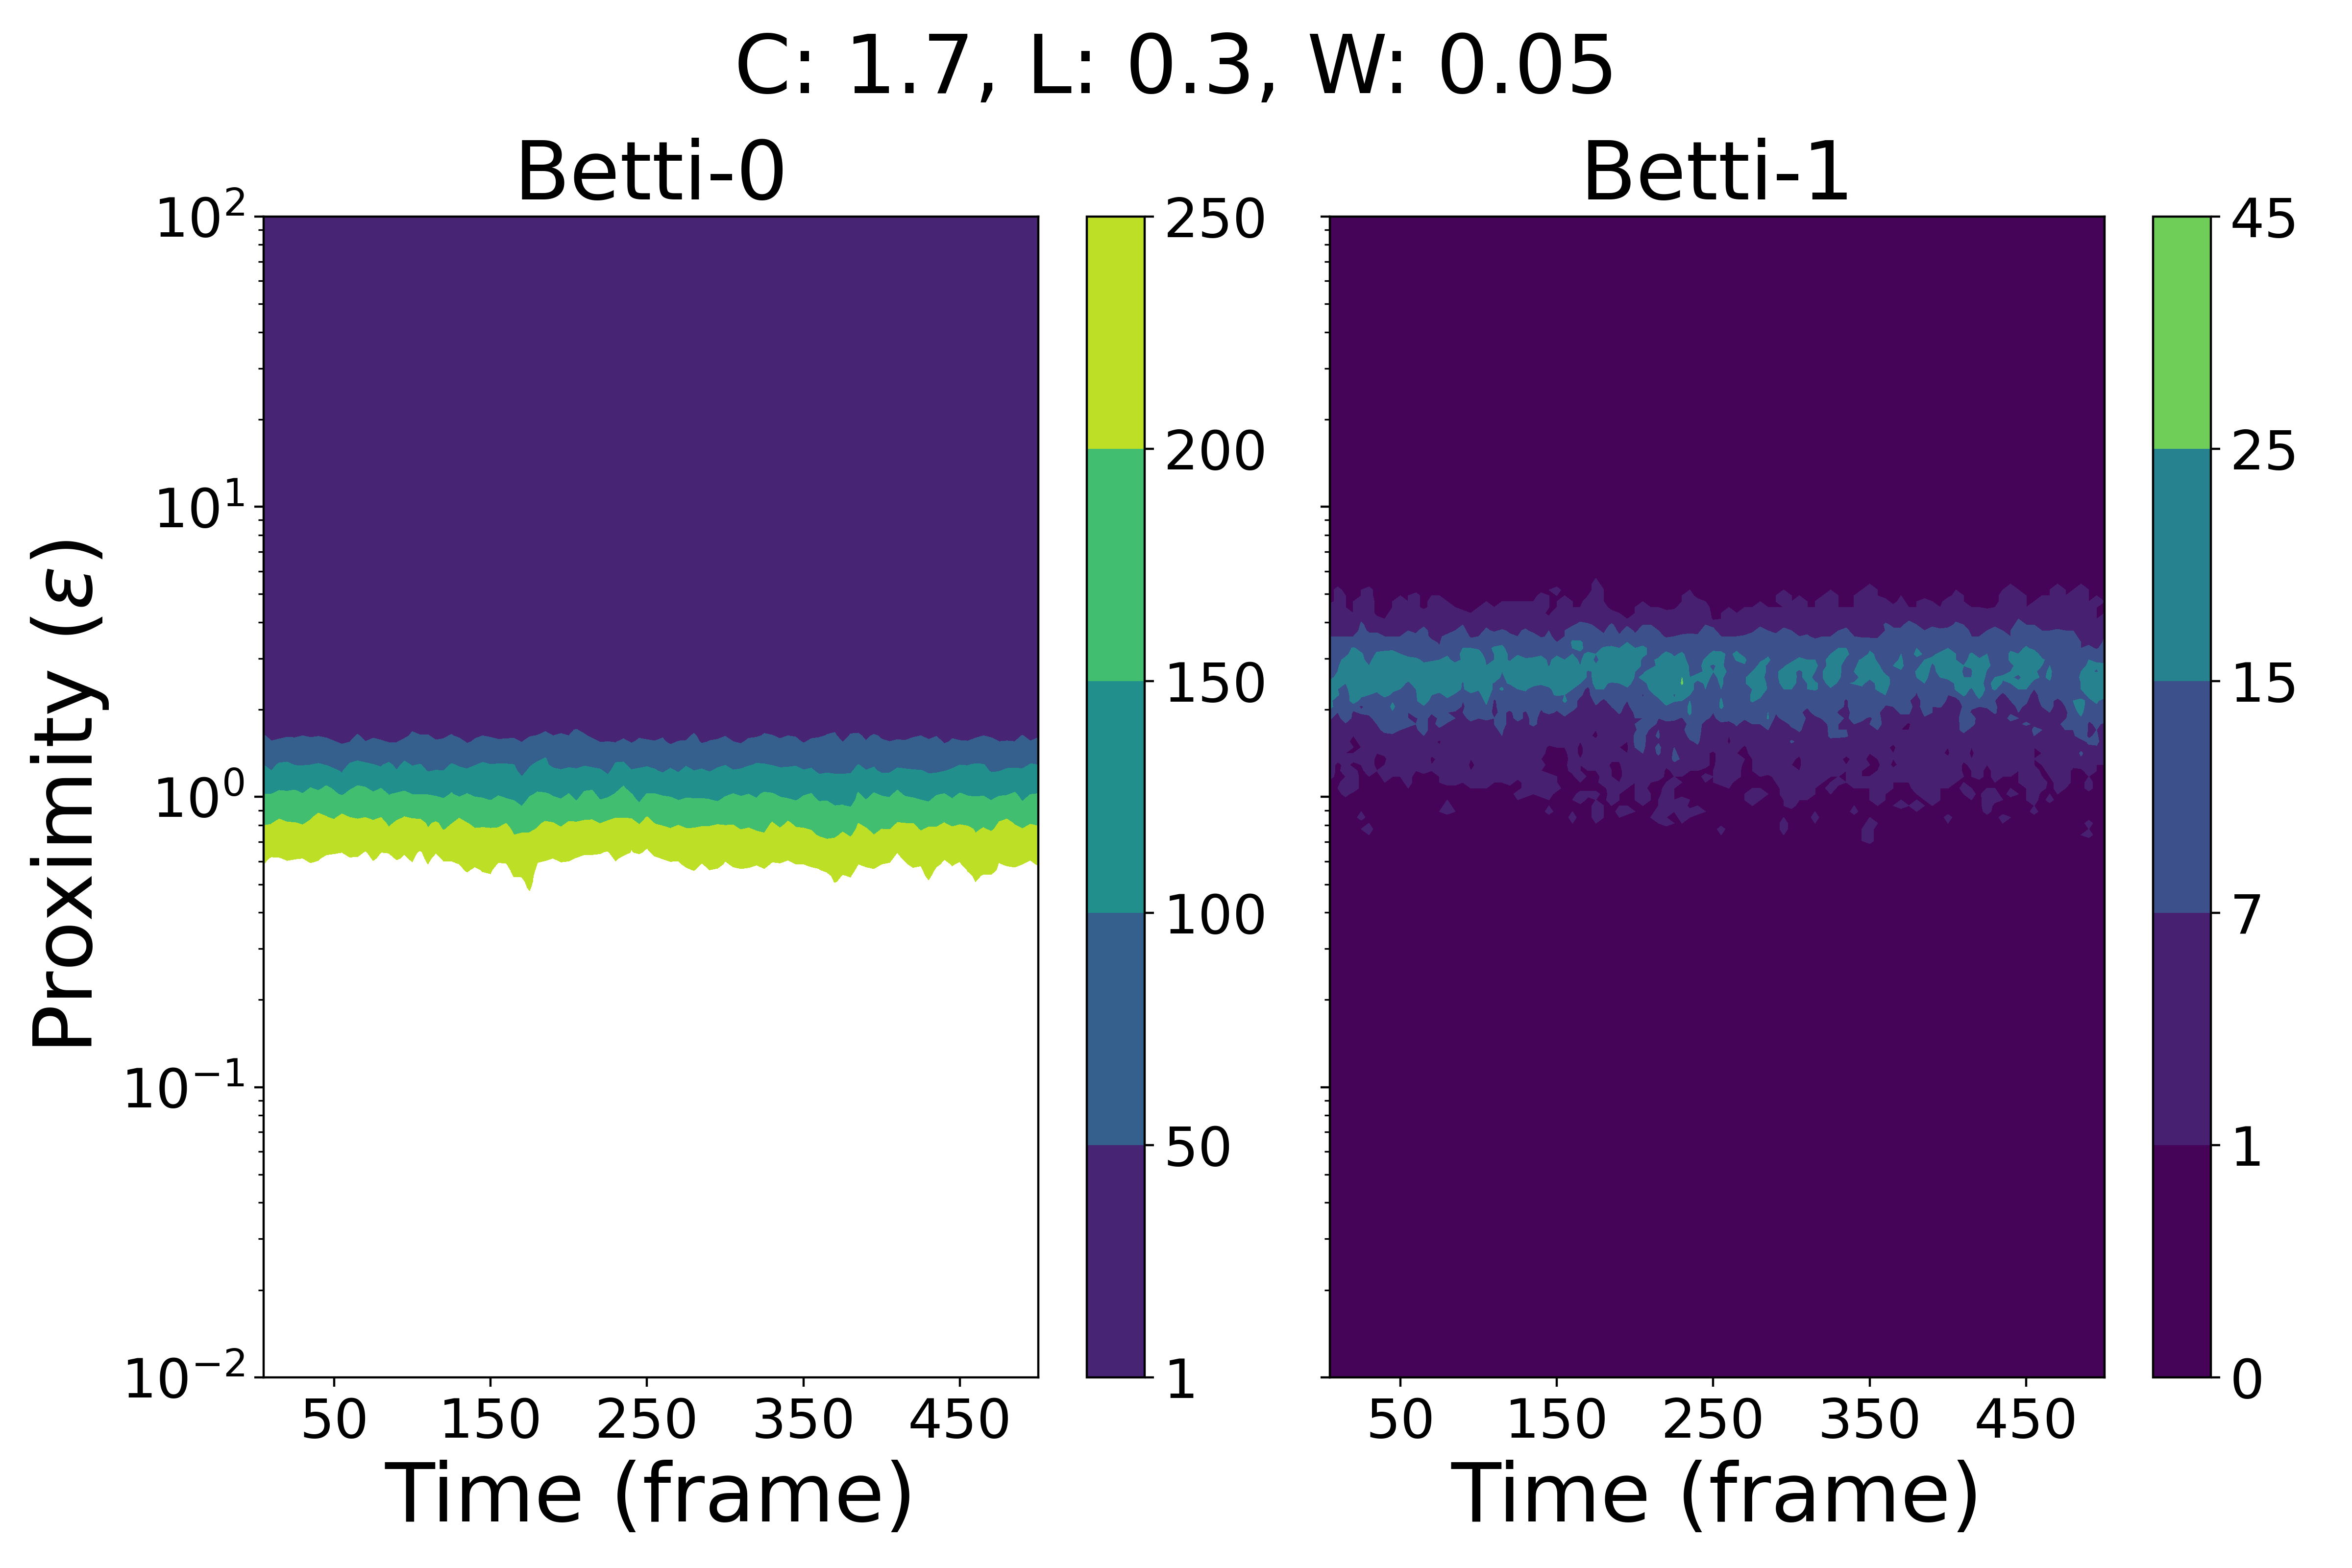

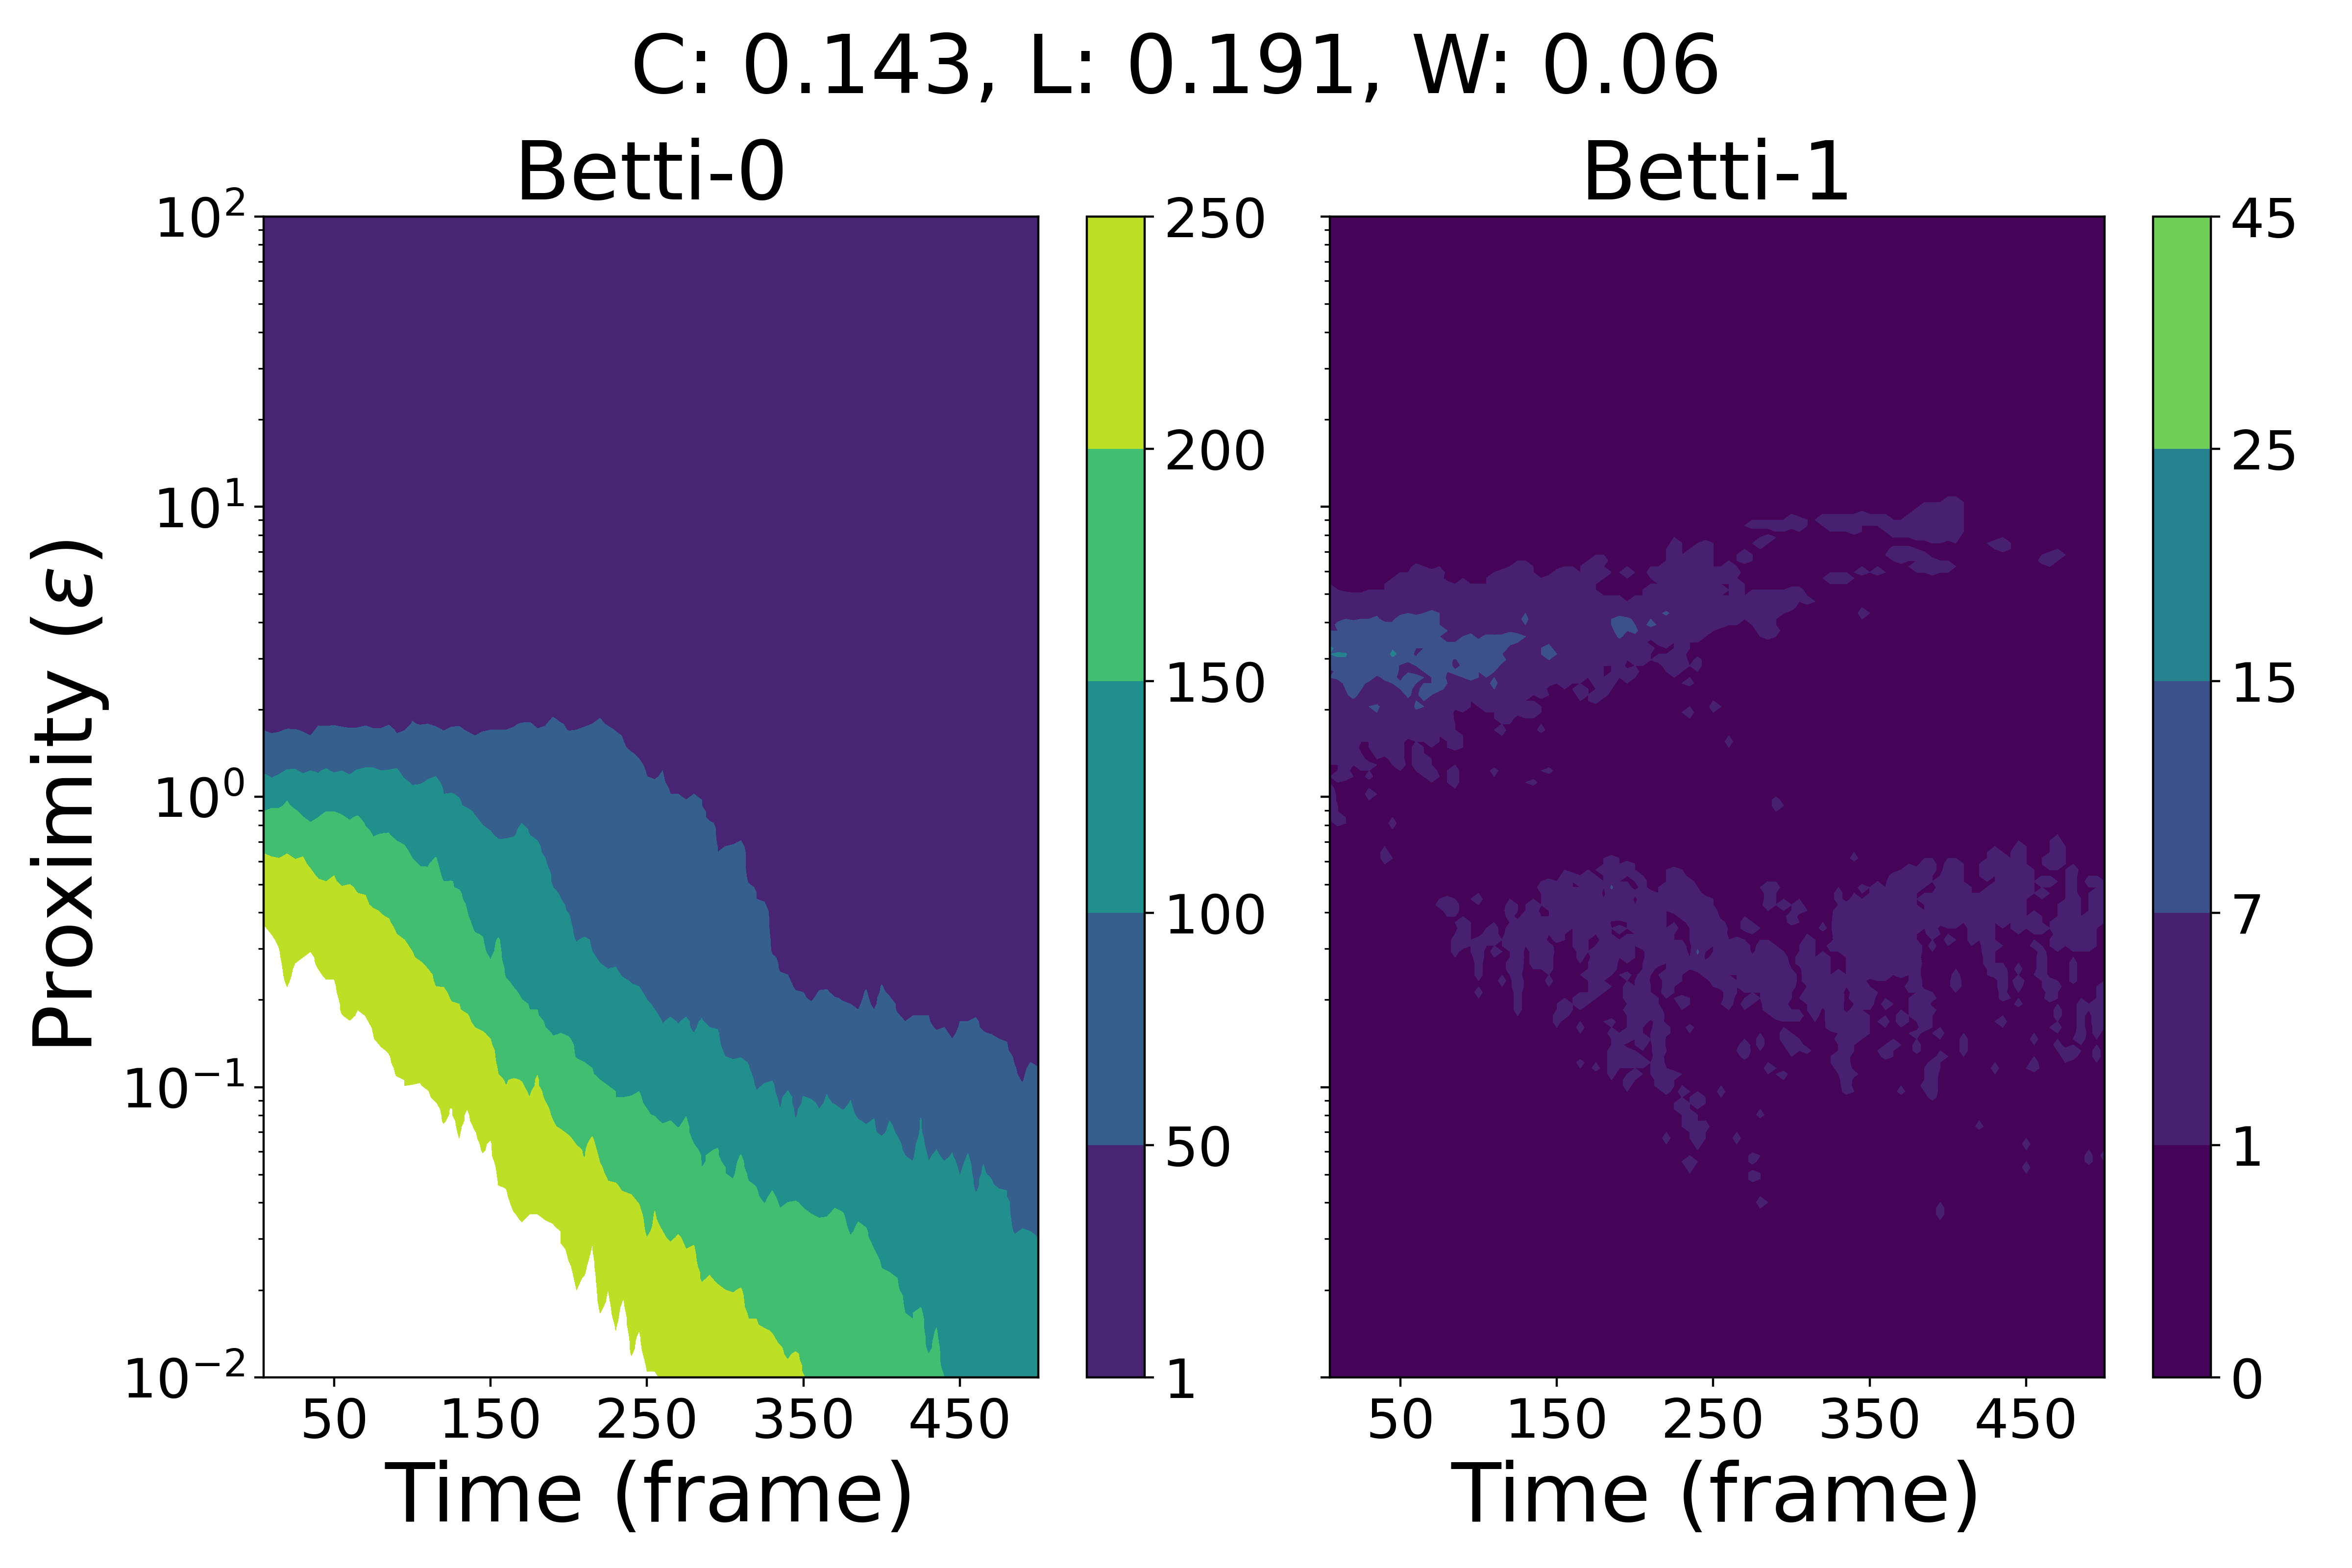

In [50]:
from Modules_CLW.AABC6_run_ABC_crocker import run_ABC_crocker_aabc

'''Compute crockers for specific Betti numbers given a trajectory dataframe for new ABC median estimated C,L,W values

Inputs:
    C - Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter
    T0 - Initial time of simulation
    TF - End time of simulation
    DT - How often to make a new frame of data
    num_agents - number of cell agents to be in the simulation

Requirements:
    df.pkl - Ground truth data frame simulation
    medians_aabc.npy - ABC median values
    df_AABC.pkl - ABC median data frame simulation
    
Output: 
    true_crocker.png - Ground truth crocker plot 
    AABC_crocker.png - ABC median crocker plot 
    crocker_differences_aabc.npy - calculated difference between the two crocker plots 
    
'''

run_ABC_crocker_aabc(C,L,W,T0,TF,DT,num_agents)

# display true crocker plot 
true_crocker_name = f"Chosen_C_{str(C).zfill(2)}_L_{str(L).zfill(2)}_W_{str(W).zfill(2)}/true_crocker.png"
display(Image(filename=true_crocker_name, width=600))

# display ABC crocker plot 
AABC_crocker_name = f"Chosen_C_{str(C).zfill(2)}_L_{str(L).zfill(2)}_W_{str(W).zfill(2)}/AABC_crocker.png"
display(Image(filename=AABC_crocker_name, width=600))

### Step 2b (Optional): Statistical Verification

#### 2b.1 Generate more samples based on the posterior densities

For the sake of time and space, we have skipped the next two steps and have given results needed for both Model_AL and Model_DO in order to complete step 2b.3. The code for Model_AL for steps 2b.1 and 2b.1 are still given below. If you choose to run them, it may take several hours due to the time intensive calculations.

In [54]:
from Modules_CLW.STAT1_run_posterior_samples import run_posterior_samples

'''Run a number of simulations where the acceptance probability is based on the posterior densities

Inputs:
    T0 - Initial time of simulation
    TF - End time of simulation
    DT - How often to make a new frame of data
    in_num_agents - number of cell agents to be in the simulation
    num_post_samples - number of posterior simulations to run 

Requirements:
    posteriors.npy - posteriors that generated ABC_posterior_densities
    ic_vec.npy - vector of initial conditions
    
Output: 
    For each simulation:
    df.pkl - the resulting dataframe of cells over the simulation with random C, L, and W values with a positive posterior value
    pars.npy - file of parameters used in random simulation
    position.gif - gif of C,L,W simulation  
    
'''

num_post_samples = 50 

# Uncomment to run this step
# run_posterior_samples(C,L,W,T0,TF,DT,num_agents,num_post_samples)

#### 2b.2 Generate more Crocker plots based on those new samples

In [56]:
from Modules_CLW.STAT2_run_posterior_crockers import run_posterior_crockers

'''Run a number of simulations where the acceptance probability is based on the posterior densities

Inputs:
    num_post_samples - number of posterior simulations to run 

Requirements:
    df.pkl - the resulting dataframe of cells over the simulation with random C, L, and W values with a positive posterior value
    
Output: 
    crocker_angles.npy - crocker values of random C,L,W simulation with a positive posterior value
    
'''

# Uncomment to run this step
# run_posterior_crockers(num_post_samples)

'Run a number of simulations where the acceptance probability is based on the posterior densities\n\nInputs:\n    num_post_samples - number of posterior simulations to run \n\nRequirements:\n    df.pkl - the resulting dataframe of cells over the simulation with random C, L, and W values with a positive posterior value\n\nOutput: \n    crocker_angles.npy - crocker values of random C,L,W simulation with a positive posterior value\n\n'

#### 2b.3 Run Statistical Verification

These statistical tests assess whether the posterior predictive summaries generated by each model are statistically distinguishable. Three different statistical tests are used, namely PERMANOVA, Energy Distance, and MMD. 

In [59]:
from Modules_CLW.STAT3_statistical_verification import statistical_verification

'''Run a number of simulations where the acceptance probability is based on the posterior densities

Inputs:
    C - Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter

Requirements:
    crocker_angles.npy - crocker values of random C,L,W simulation with a positive posterior value
    all_AL_matrices.npy - all crockers for Model_AL flattened and combined
    all_DO_matrices.npy - all crockers for Model_DO flattened and combined
    
Output: 
    all_AL_matrices.npy - generated if not given above
    all_DO_matrices.npy - generated if not given above
    stats_results.csv - results of statistical tests comparing distributions of Crocker plots of Model_AL and Model_DO (PERMANOVA, Energy Distance, MMD)
    
'''

statistical_verification(C,L,W)

### Step 3: Bayesian Information Criterion

#### 3.1 Calculate the BIC (and AIC) scores

Now we will calculate the BIC (and AIC) scores from the SSE between the ground truth model and AABC estimated model results.

In [63]:
from Modules_CLW.BIC_calc_bic_and_aic import calc_bic_and_aic, calc_bic_and_aic_aabc

'''Calculate the BIC score for the simulation of our chosen C, L, and W values compared to the AABC estimate

Inputs:
    C - Ratio of magnitude of attractive and respulive forces
    L - Ratio of range of attractive and respulive forces
    W - Alignment parameter

Requirements:
    crocker_differences_aabc.npy - file of difference values between ground truth crocker and AABC crocker
    
Output: 
    BIC Score - Score of model based on BIC formula
    AIC Score - Score of model based on BIC formula
    SSE - SSE between ground truth and ABC estimated crockers
    
'''

[bic_results, aic_results] = calc_bic_and_aic_aabc(C,L,W)

# to just use the ABC results instead of AABC results for calculating BIC and AIC
# [bic_results, aic_results] = calc_bic_and_aic(C,L,W)

aic_score, aic_sse_score = aic_results
bic_score, bic_sse_score = bic_results

print('BIC Score: ' + str(bic_score) + 'AIC Score: ' + str(aic_score) + ' SSE: ' + str(bic_sse_score))

BIC Score: 460014.95478718623AIC Score: 459980.56824825384 SSE: 231033175.0
